# 1. INSTALL

In [ ]:
!pip install transformers torch pandas scikit-learn

# 2. IMPORT

In [ ]:
import pandas as pd
import numpy as np
import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader

# 3. LOAD DATA

In [ ]:
df_seed = pd.read_csv('/content/youtube-comments-setengah labeling manual.csv')
df_all = pd.read_csv('/content/youtube-comments-ori.csv')

# samakan kolom
df_seed = df_seed[['textDisplay','label']].dropna()
df_seed.rename(columns={'textDisplay':'text'}, inplace=True)

df_all = df_all[['textDisplay']].dropna()
df_all.rename(columns={'textDisplay':'text'}, inplace=True)

# 4. ENCODE LABEL

In [ ]:
le = LabelEncoder()
df_seed['label_enc'] = le.fit_transform(df_seed['label'])

# 5. LOAD MODEL

In [ ]:
model_name = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

# 6. DATASET CLASS

In [ ]:
class TextDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.texts = list(texts)
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=64,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in enc.items()}

        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx])

        return item

# 7. TRAIN MODEL DARI DATA MANUAL

In [ ]:
train_dataset = TextDataset(df_seed['text'], df_seed['label_enc'].values)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

print("🚀 Training model dari data manual...")

model.train()

for epoch in range(3):
    total_loss = 0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

🚀 Training model dari data manual...
Epoch 1 Loss: 38.0342
Epoch 2 Loss: 31.2385
Epoch 3 Loss: 22.3018


# 8. AUTO LABELING

In [ ]:
print("🔮 Auto labeling semua data...")

pseudo_dataset = TextDataset(df_all['text'])
pseudo_loader = DataLoader(pseudo_dataset, batch_size=16)

model.eval()

all_preds = []
all_conf = []

with torch.no_grad():
    for batch in pseudo_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        probs = torch.softmax(outputs.logits, dim=1)

        all_preds.extend(torch.argmax(probs, dim=1).cpu().numpy())
        all_conf.extend(torch.max(probs, dim=1).values.cpu().numpy())


🔮 Auto labeling semua data...


# 9. SIMPAN HASIL

In [ ]:
df_all['label'] = le.inverse_transform(all_preds)
df_all['confidence'] = all_conf

# simpan semua
df_all.to_csv('/content/hasil_auto_labeling.csv', index=False)

# simpan yang confidence tinggi
df_high = df_all[df_all['confidence'] > 0.85]
df_high.to_csv('/content/hasil_confident.csv', index=False)

print("✅ Selesai!")
print("Total data:", len(df_all))
print("High confidence:", len(df_high))

✅ Selesai!
Total data: 1200
High confidence: 86


# 10. Cek Distribusi Label

In [ ]:
print(df_all['label'].value_counts())

label
netral        405
kritik        327
pertanyaan    286
pujian        129
saran          53
Name: count, dtype: int64


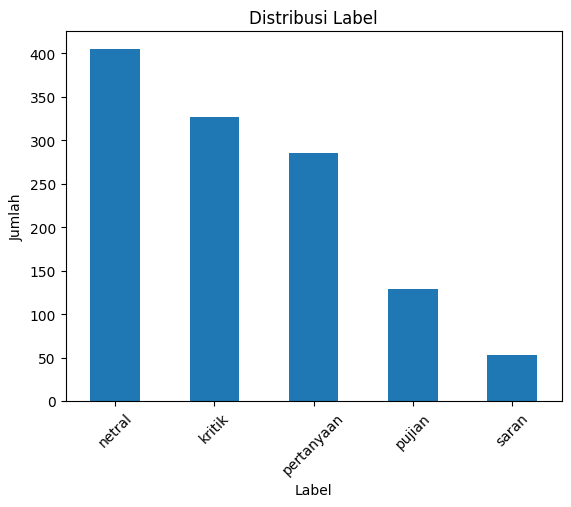

In [ ]:
import matplotlib.pyplot as plt

df_all['label'].value_counts().plot(kind='bar')
plt.title("Distribusi Label")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.xticks(rotation=45)
plt.show()